# 10: Formant Trajectories, Vocal Tract Dynamics & Articulatory Dispersion

## 1. Research Scope & Objectives
This notebook evaluates resonance formant frequency tracking ($F_1, F_2, F_3, F_4$), Formant Dispersion ($F_D$), and estimated Vocal Tract Length (VTL) to distinguish physical articulatory acoustics from vocoder synthesis approximations.

### Mathematical Formulations
Formant Dispersion:
$$F_D = \frac{1}{3}\sum_{i=1}^3 (F_{i+1} - F_i)$$
Estimated Vocal Tract Length:
$$\text{VTL} = \frac{c}{2 F_D}, \quad c = 350\text{ m/s}$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import soundfile as sf, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa
from src.utils.config import path_config

sns.set_theme(style="whitegrid")
manifest_path = os.path.join(path_config.data_processed, "protocol_manifest.parquet")
df = pd.read_parquet(manifest_path)

## 2. Formant Frequency Tracking via LPC Polynomial Roots

In [2]:
def extract_formants_lpc(y, sr=16000, n_formants=4):
    a = librosa.lpc(y, order=16)
    roots = np.roots(a)
    roots = roots[np.imag(roots) >= 0]
    angles = np.arctan2(np.imag(roots), np.real(roots))
    freqs = sorted(angles * (sr / (2 * np.pi)))
    formants = [f for f in freqs if 200 < f < (sr / 2 - 200)]
    while len(formants) < n_formants:
        formants.append(0.0)
    return formants[:n_formants]

sample_set = df[df.split == "train"].sample(100, random_state=42)
formant_data = []
for _, row in sample_set.iterrows():
    y, sr = sf.read(row.file_path)
    f1, f2, f3, f4 = extract_formants_lpc(y, sr)
    fd = (f2 - f1 + f3 - f2 + f4 - f3) / 3.0 if f4 > 0 else (f2 - f1)
    vtl = (35000.0) / (2.0 * (fd + 1e-5))
    formant_data.append({
        "key": row.key,
        "F1": f1,
        "F2": f2,
        "F3": f3,
        "F4": f4,
        "Formant_Dispersion": fd,
        "Vocal_Tract_Length_cm": vtl
    })
formant_df = pd.DataFrame(formant_data)

c:\Users\tamimystic\.conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\tamimystic\AppData\Local\Temp\ipykernel_17376\3245323552.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=formant_df, x="key", y="Formant_Dispersion", palette=["#2ecc71", "#e74c3c"], ax=axes[1])


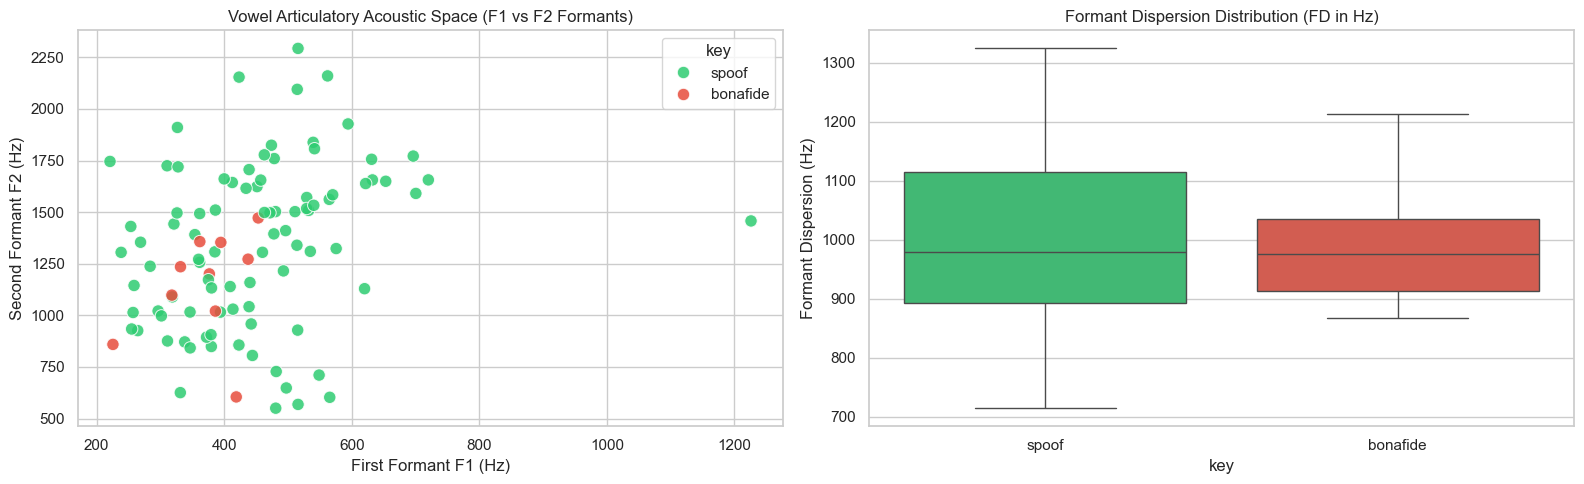

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=formant_df, x="F1", y="F2", hue="key", palette=["#2ecc71", "#e74c3c"], s=80, alpha=0.85, ax=axes[0])
axes[0].set_title("Vowel Articulatory Acoustic Space (F1 vs F2 Formants)")
axes[0].set_xlabel("First Formant F1 (Hz)")
axes[0].set_ylabel("Second Formant F2 (Hz)")

sns.boxplot(data=formant_df, x="key", y="Formant_Dispersion", palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Formant Dispersion Distribution (FD in Hz)")
axes[1].set_ylabel("Formant Dispersion (Hz)")
plt.tight_layout()
plt.show()